# Libraries

In [22]:
import numpy as np
import pandas as pd

from sklearn.calibration import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import datasets
from scipy.cluster.hierarchy import dendrogram, linkage 

from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier

import path
import re
import pickle
import joblib
import shap
from pathlib import Path
import os

from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import fcluster

# Load csv

In [23]:
file_path = os.path.join("..", "data", "shopping_trends.csv")
df = pd.read_csv(file_path)
df.drop('Location', axis=1, inplace=True)

df_original = df.copy()
df_original = df_original.drop('Customer ID', axis=1)

display(df_original.head())
display(df_original.info())
df_original['Gender'].value_counts()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Size                      3900 non-null   object 
 6   Color                     3900 non-null   object 
 7   Season                    3900 non-null   object 
 8   Review Rating             3900 non-null   float64
 9   Subscription Status       3900 non-null   object 
 10  Payment Method            3900 non-null   object 
 11  Shipping Type             3900 non-null   object 
 12  Discount Applied          3900 non-null   object 
 13  Promo Code Used           3900 non-null   object 
 14  Previous

None

Gender
Male      2652
Female    1248
Name: count, dtype: int64

## Get dummies and scale the dataset

In [24]:
df_dummied = pd.get_dummies(df_original, drop_first=True)
display(df_dummied.head())


,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Male,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,3.1,14,True,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,19,64,3.1,2,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,50,73,3.1,23,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,21,90,3.5,49,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,45,49,2.7,31,True,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False


## Silhouette score

Silhouette Plot for K=2


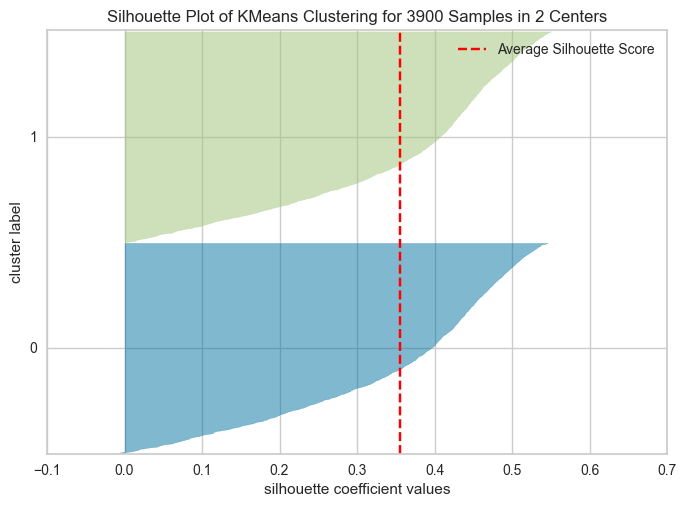

Silhouette Plot for K=3


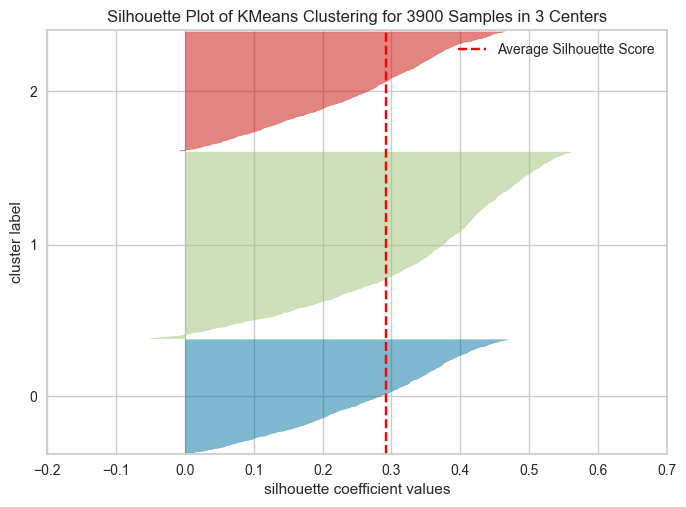

Silhouette Plot for K=4


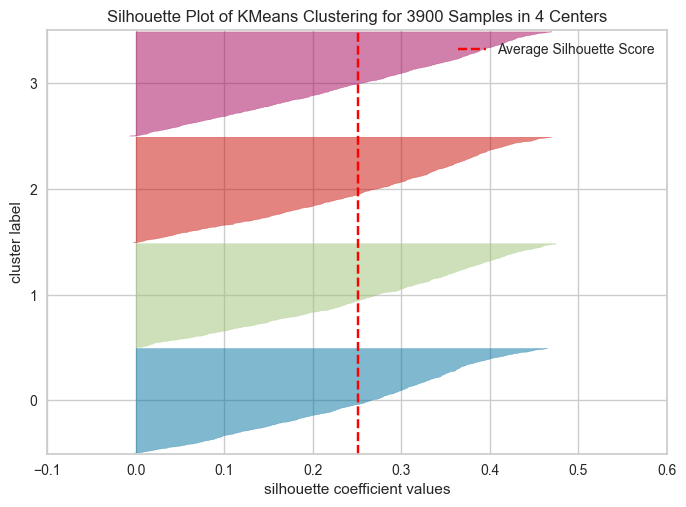

In [25]:
for clu in range(2, 5): 
    model_kmeans = KMeans(n_clusters=clu, random_state=42, n_init=10)
    visualizer = SilhouetteVisualizer(model_kmeans, colors='yellowbrick')
    visualizer.fit(df_dummied) 
    
    print(f"Silhouette Plot for K={clu}")
    visualizer.show()

So highest silhouette score with 2 clusters

## Elbow method

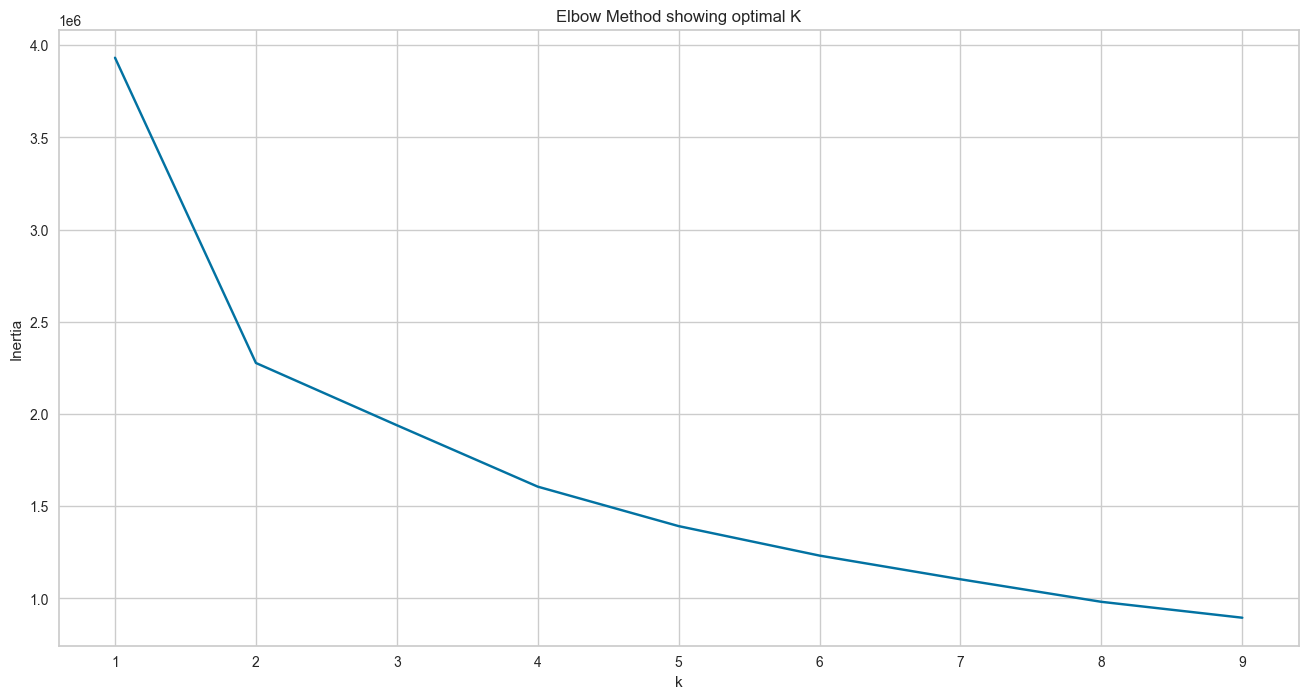

In [26]:
inertia = []

K = range(1,10)

for k in K:

    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(df_dummied)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K,inertia,'bx-')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method showing optimal K")
plt.show()

## Ward's Dendrogram

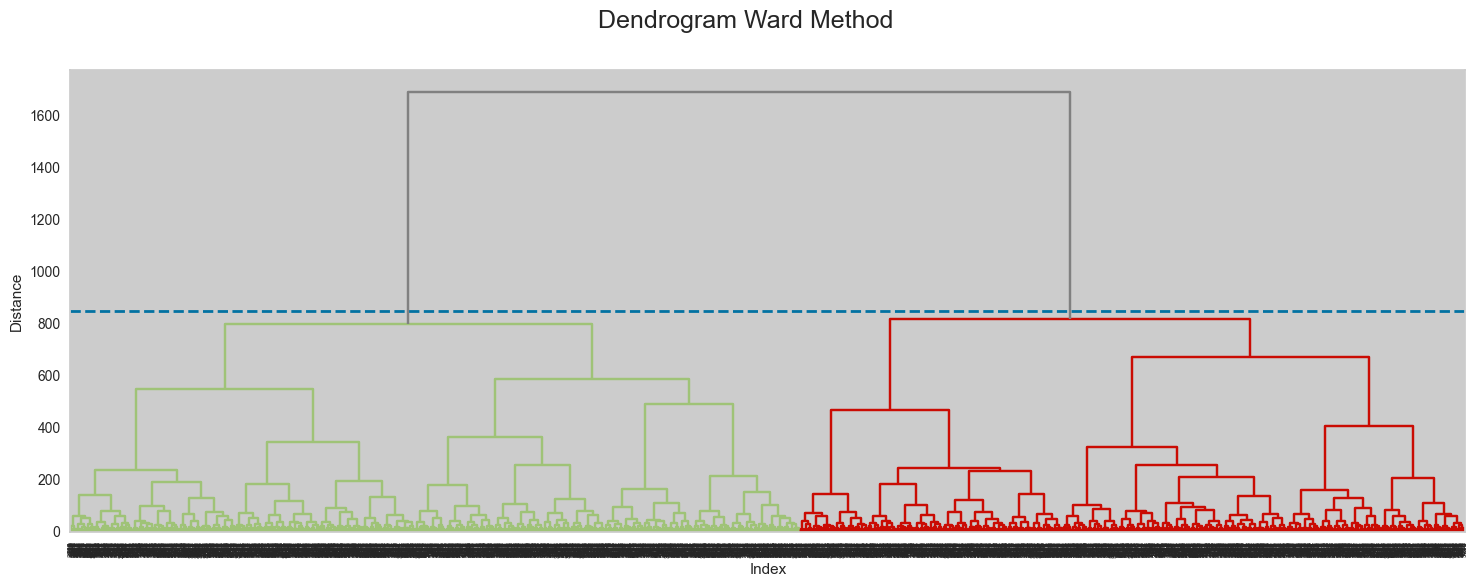

clusters: [0 1]


In [27]:
dist_ward = linkage(df_dummied, method="ward")

plt.figure(figsize=(18, 6))
dendrogram(
    dist_ward,
    leaf_rotation=90,
    color_threshold=850,
    above_threshold_color="grey"
)
plt.axhline(y=850, linestyle="--", linewidth=2)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Ward Method", fontsize=18)
plt.show()

labels_ward = fcluster(
    dist_ward,
    t=850,
    criterion="distance"
)

labels_ward = np.unique(labels_ward, return_inverse=True)[1]
print("clusters:", np.unique(labels_ward))

In [28]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_dummied)
df_scaled = pd.DataFrame(df_scaled, columns=df_dummied.columns)
display(df_scaled.head())

kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_original['segment'] = clusters
display(df_original['segment'].value_counts())
df_original

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Male,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,0.718913,-0.285629,-0.907584,-0.785831,0.685994,-0.207508,4.669798,-0.195803,-0.207508,-0.210847,...,-0.455856,-0.441422,-0.458315,2.269674,-0.403903,-0.419662,2.489091,-0.406476,-0.410749,-0.400461
1,-1.648629,0.178852,-0.907584,-1.616552,0.685994,-0.207508,-0.214142,-0.195803,-0.207508,-0.210847,...,-0.455856,-0.441422,-0.458315,-0.440592,-0.403903,-0.419662,2.489091,-0.406476,-0.410749,-0.400461
2,0.390088,0.558882,-0.907584,-0.162789,0.685994,-0.207508,-0.214142,-0.195803,-0.207508,-0.210847,...,2.193677,-0.441422,-0.458315,-0.440592,-0.403903,-0.419662,-0.401753,-0.406476,-0.410749,2.497123
3,-1.517099,1.276716,-0.349027,1.637107,0.685994,-0.207508,-0.214142,-0.195803,-0.207508,-0.210847,...,-0.455856,-0.441422,2.181905,-0.440592,-0.403903,-0.419662,-0.401753,-0.406476,-0.410749,2.497123
4,0.061263,-0.454531,-1.466141,0.391025,0.685994,-0.207508,4.669798,-0.195803,-0.207508,-0.210847,...,-0.455856,-0.441422,2.181905,-0.440592,-0.403903,-0.419662,-0.401753,-0.406476,-0.410749,-0.400461


segment
1    3301
0     599
Name: count, dtype: int64

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,segment
0,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,1
1,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,1
2,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1
3,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,0
4,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,1
3896,52,Female,Backpack,Accessories,49,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,1
3897,46,Female,Belt,Accessories,33,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,1
3898,44,Female,Shoes,Footwear,77,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly,0


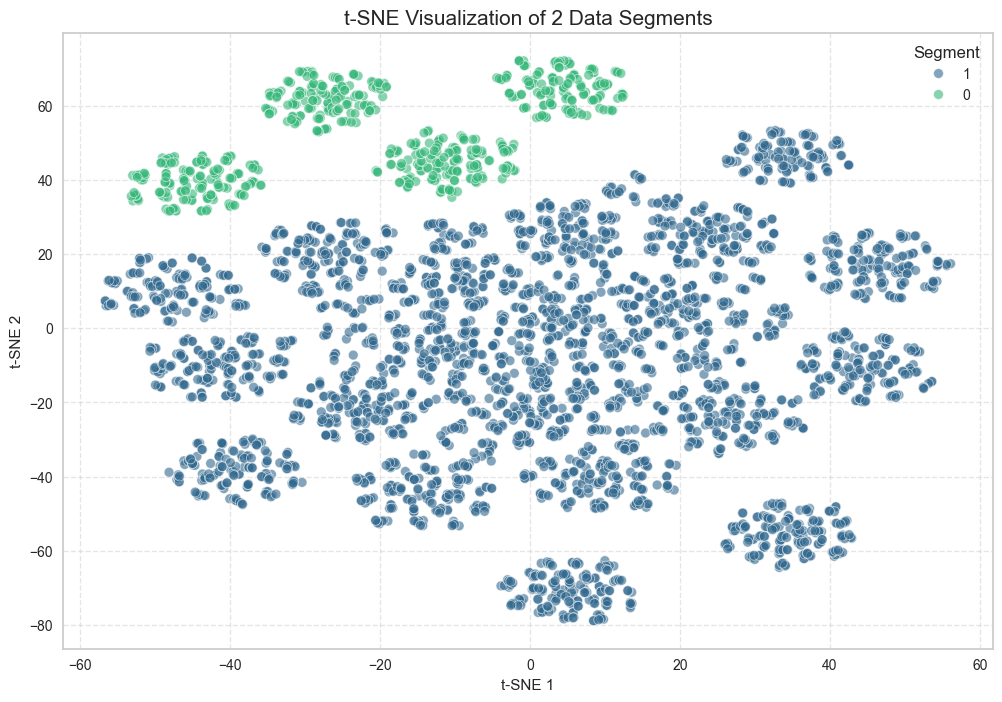

In [29]:
tsne = TSNE(n_components=2, perplexity=50, init='pca', random_state=42)
X_tsne = tsne.fit_transform(df_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
tsne_df['segment'] = clusters

plot_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'cluster': clusters.astype(str) # Convert to string so the legend treats them as discrete categories
})

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df, 
    x='x', 
    y='y', 
    hue='cluster', 
    palette='viridis', 
    alpha=0.6, 
    s=50
)

plt.title('t-SNE Visualization of 2 Data Segments', fontsize=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
display(df_original.groupby('segment').mean(numeric_only=True))

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
segment,,,,
0,44.442404,60.255426,3.790651,25.232053
1,44.000606,59.675250,3.742563,25.373220


Dead end, tsne did not provide a useful insight

## I will only scale the numerical columns

In [31]:
from sklearn.preprocessing import StandardScaler

num_cols = df_original.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()

# We create a copy for the model so we don't overwrite our 'real' numbers in df_original
df_numerical = df_original.copy()
df_numerical[num_cols] = scaler.fit_transform(df_original[num_cols])

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,segment,Gender_Male,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,0.718913,-0.285629,-0.907584,-0.785831,1,True,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
1,-1.648629,0.178852,-0.907584,-1.616552,1,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,0.390088,0.558882,-0.907584,-0.162789,1,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,-1.517099,1.276716,-0.349027,1.637107,0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,0.061263,-0.454531,-1.466141,0.391025,1,True,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


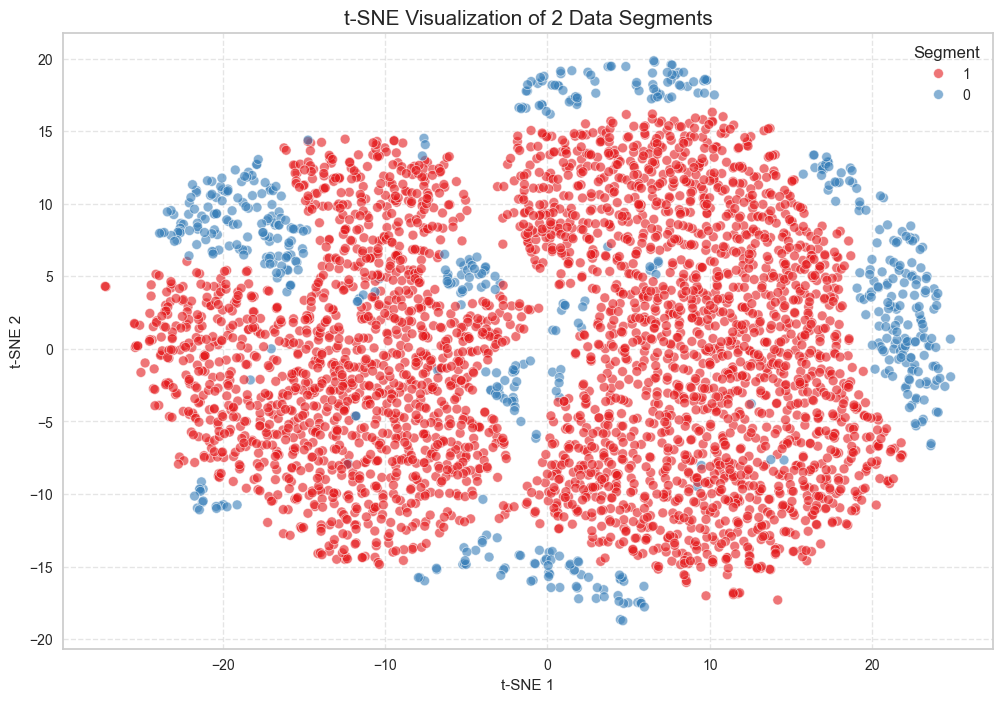

In [32]:
df_final_scaled = pd.get_dummies(df_numerical, drop_first=True)
display(df_final_scaled.head())

tsne = TSNE(n_components=2, perplexity=100, init='pca', random_state=42)

X_tsne = tsne.fit_transform(df_final_scaled)

# Create a plotting dataframe
tsne_df = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
tsne_df['segment'] = clusters

# Create a clean dataframe for plotting
plot_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'cluster': clusters.astype(str) # Convert to string so the legend treats them as discrete categories
})

plt.figure(figsize=(12, 8))

# Use a high-contrast palette to see the 2 segments clearly
sns.scatterplot(
    data=plot_df, 
    x='x', 
    y='y', 
    hue='cluster', 
    palette='Set1', 
    alpha=0.6, 
    s=50
)

plt.title('t-SNE Visualization of 2 Data Segments', fontsize=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [33]:
df['segment'] = clusters

display(df.head())

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,segment
0,1,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,1
1,2,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,1
2,3,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1
3,4,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,0
4,5,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1


In [34]:
file_path = os.path.join("..", "data", "twice_segmented_customer_analysis.csv")
df.to_csv(file_path, index=False)
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,segment
0,1,55,Male,Blouse,Clothing,53,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,1
1,2,19,Male,Sweater,Clothing,64,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,1
2,3,50,Male,Jeans,Clothing,73,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1
3,4,21,Male,Sandals,Footwear,90,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,0
4,5,45,Male,Blouse,Clothing,49,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,1
3896,3897,52,Female,Backpack,Accessories,49,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,1
3897,3898,46,Female,Belt,Accessories,33,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,1
3898,3899,44,Female,Shoes,Footwear,77,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly,0


In [35]:
# Create a quick summary table
summary = df.groupby('segment')[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].mean()
summary['Count'] = df_original['segment'].value_counts()
display(summary)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Count
segment,,,,,
0,44.442404,60.255426,3.790651,25.232053,599
1,44.000606,59.675250,3.742563,25.373220,3301


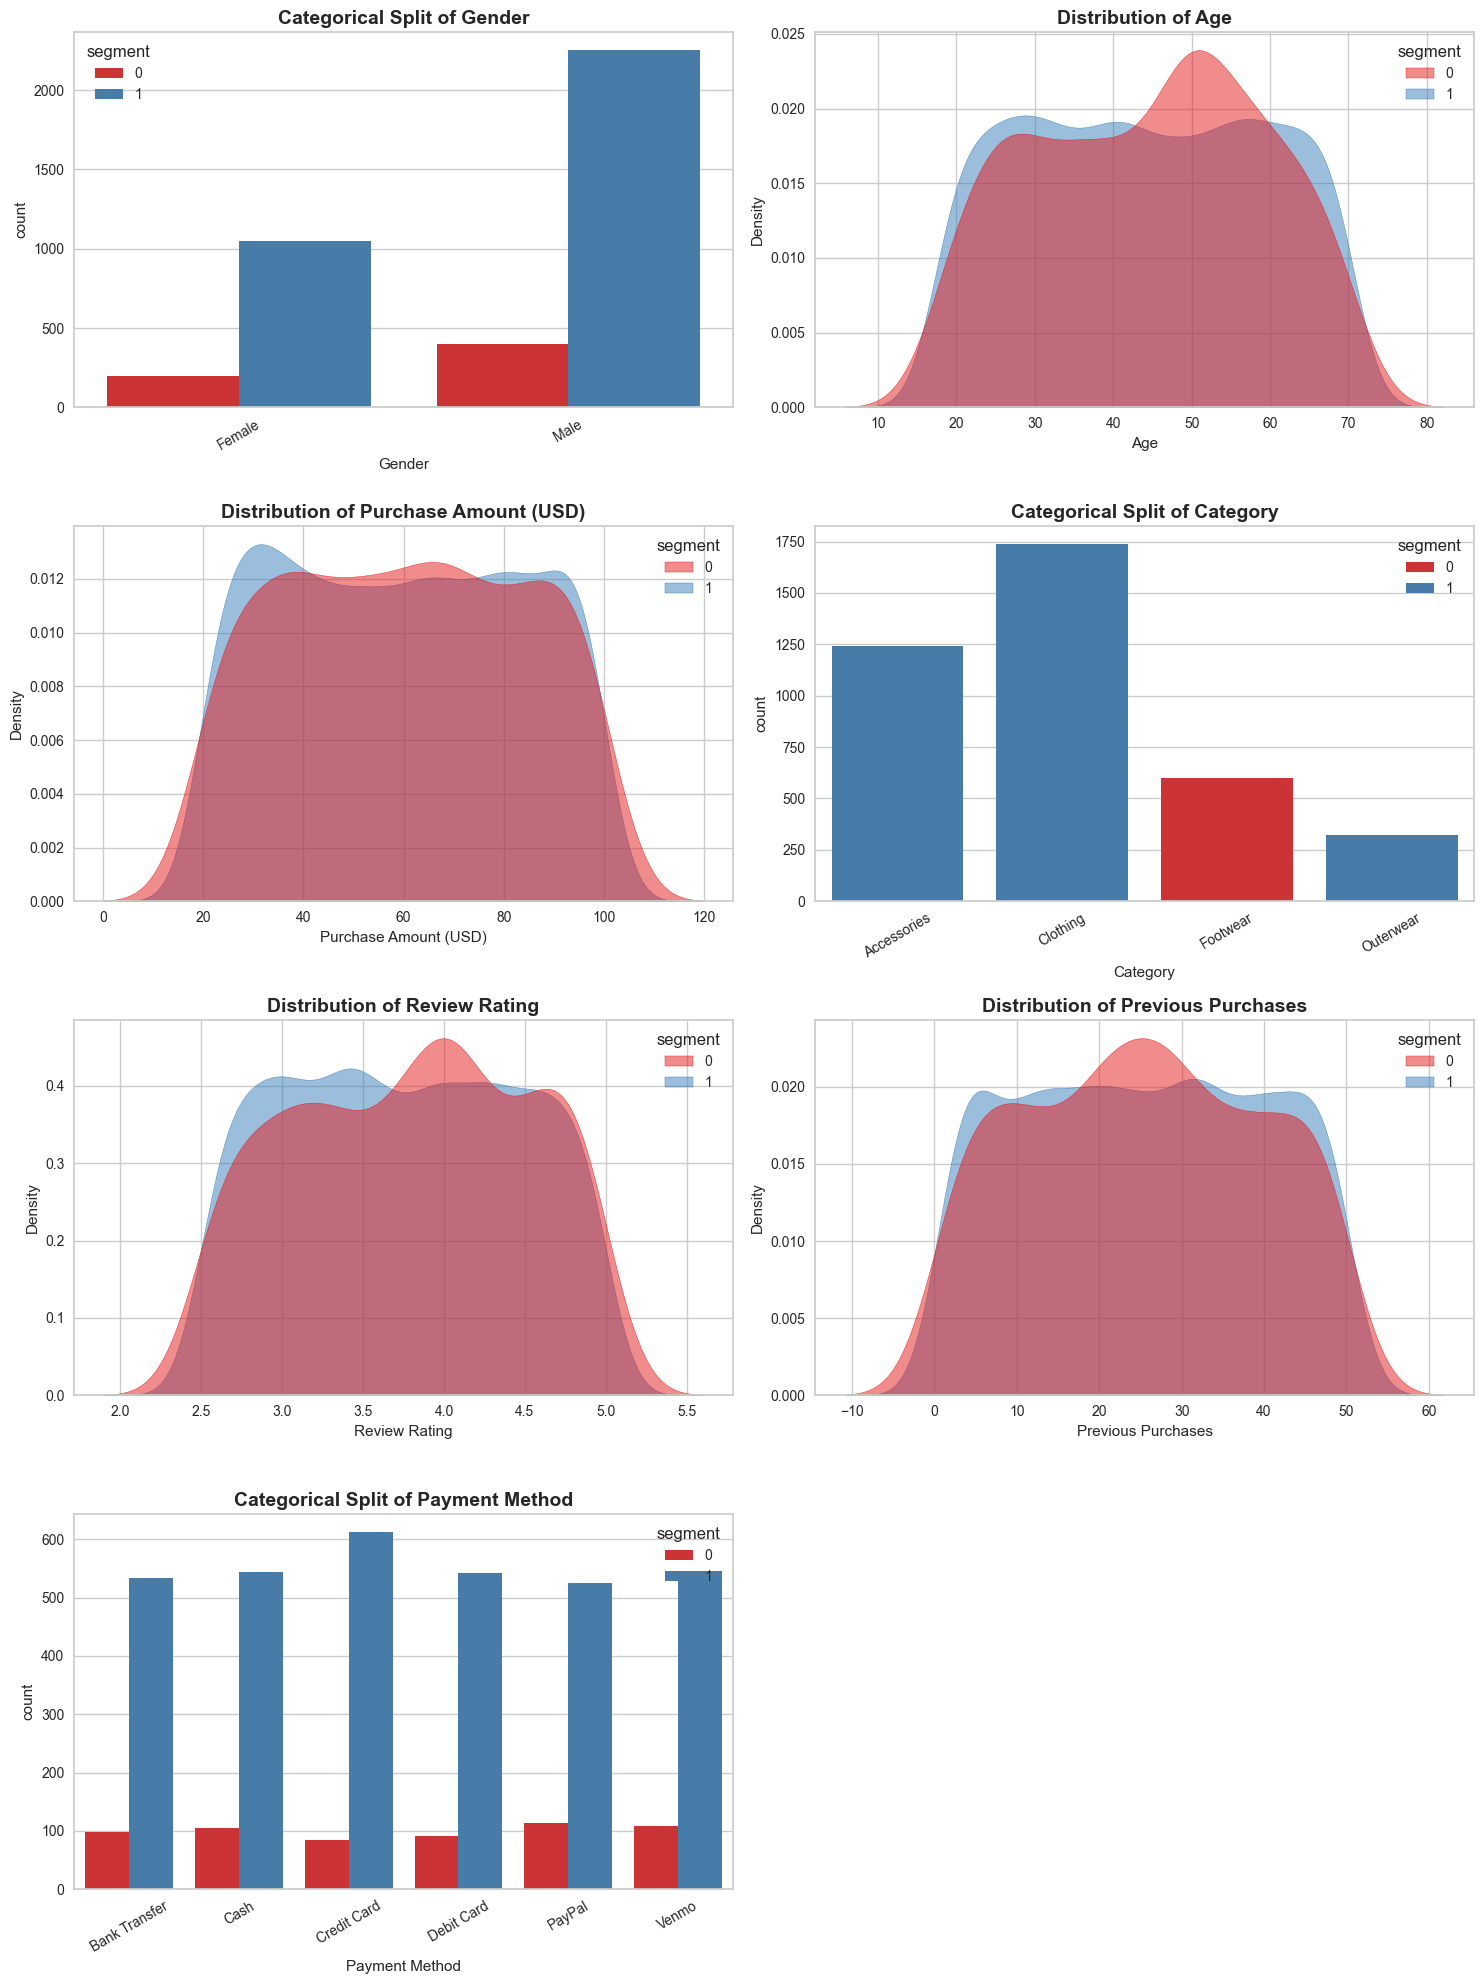

In [36]:
# Ensure 'segment' is in df_original before running your loop
# df_original['segment'] = clusters 

cols = ['Gender', 'Age', 'Purchase Amount (USD)', 'Category', 
        'Review Rating', 'Previous Purchases', 'Payment Method']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20)) # Slightly smaller for readability
axes = axes.flatten()

for i, col in enumerate(cols):
    if col in ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']:
        # Use KDE for a cleaner look at overlapping distributions
        sns.kdeplot(data=df, x=col, hue='segment', fill=True, 
                    ax=axes[i], palette='Set1', common_norm=False, alpha=0.5)
        axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    
    else:
        # For Categorical: Compare percentages rather than raw counts if segments are uneven
        sns.countplot(data=df, x=col, hue='segment', 
                      ax=axes[i], palette='Set1', order=sorted(df[col].unique()))
        
        axes[i].set_title(f'Categorical Split of {col}', fontsize=14, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=30)

# Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

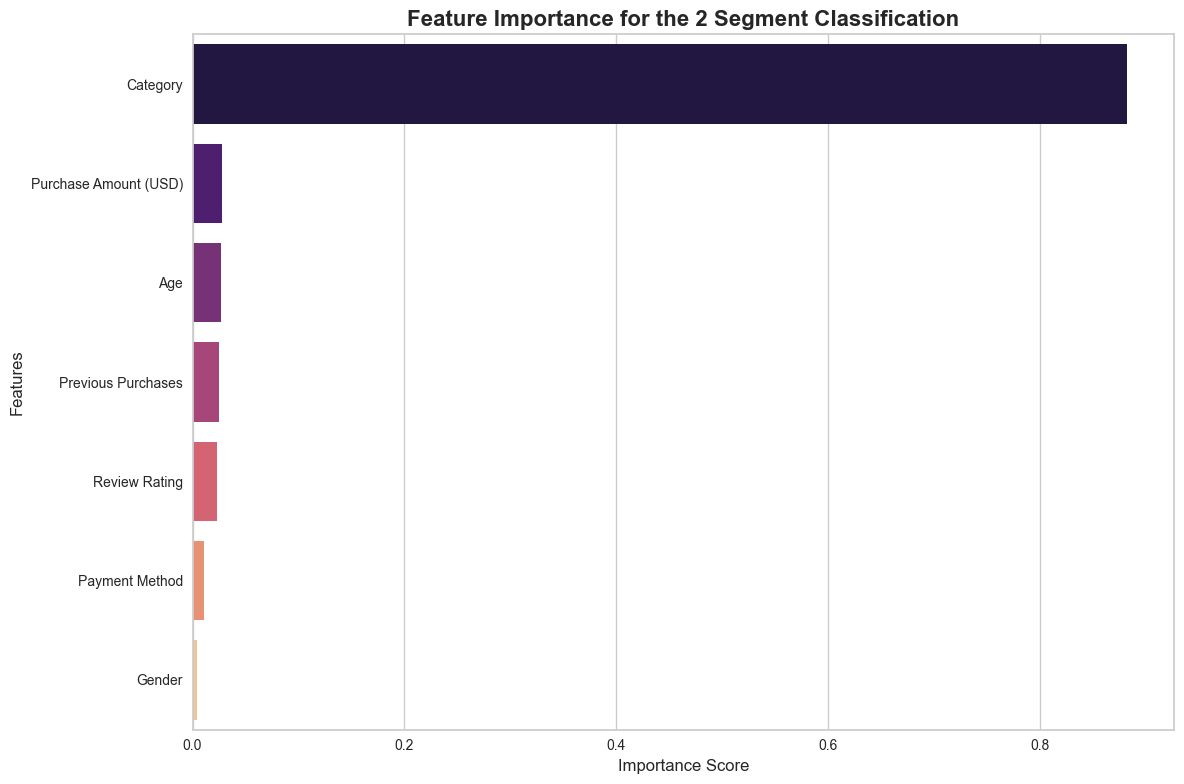

--- Feature Importance Scores ---
                 Feature  Importance
3               Category    0.882363
2  Purchase Amount (USD)    0.028025
1                    Age    0.026738
5     Previous Purchases    0.025352
4          Review Rating    0.022973
6         Payment Method    0.010629
0                 Gender    0.003920


In [37]:
cols = ['Gender', 'Age', 'Purchase Amount (USD)', 'Category', 
        'Review Rating', 'Previous Purchases', 'Payment Method']

df_model = df[cols].copy()
y = df['segment']

le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_model, y)

importances = rf.feature_importances_
feature_names = df_model.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')

plt.title('Feature Importance for the 2 Segment Classification', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Display the numerical values
print("--- Feature Importance Scores ---")
print(feature_importance_df)

## The Strategy Insight

Strategic Pivot: Prioritize broad-reach Apparel and Lifestyle campaigns for the Mass Market (Segment 1), while creating a highly targeted "Footwear Specialist" track for Segment 0.


## Final Executive Insight: The "Mass Market" vs. "Footwear Specialist" Split 

The dataset is dominated by one massive, diverse group, with a much smaller secondary group defined by a very specific product interest.

Segment 0 (The Specialist): A much smaller, niche group containing only a fraction of both male and female shoppers. This segment is defined almost exclusively by their focus on Footwear.

Segment 1 (Mass Market): This is a high-volume, Gender-Neutral cluster. It contains nearly all female shoppers and the vast majority of males. This group is primarily interested in Clothing and Accessories.